## Paso 1: Importar librerías

In [1]:
import numpy as np
import pandas as pd 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import pairwise_distances, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

## Paso 2: Cargar los datos

In [2]:
# Reemplaza 'archivo.csv' con la ruta de tu archivo real
df = pd.read_csv("../datos_inmuebles.csv")

## Paso 3: Exploración inicial

In [3]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tamaño_m2         200 non-null    int64  
 1   Habitaciones      200 non-null    int64  
 2   Ubicación         200 non-null    object 
 3   Año_Construcción  200 non-null    int64  
 4   Precio_USD        200 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB


In [17]:
# Dimensiones
df.shape

(200, 6)

In [5]:
# Primeras filas
df.head()

,Tamaño_m2,Habitaciones,Ubicación,Año_Construcción,Precio_USD
0,152,5,Suburbio,2015,299781.0
1,229,5,Periferia,1991,385551.0
2,142,3,Suburbio,2020,258381.0
3,64,5,Periferia,1998,135449.0
4,156,4,Suburbio,1991,277521.0


In [6]:
# Tratamiento de datos categóricos

df = pd.get_dummies(df, columns=['Ubicación'], dtype=int,drop_first=True)



In [7]:
# Estadísticas descriptivas
df.describe()

,Tamaño_m2,Habitaciones,Año_Construcción,Precio_USD,Ubicación_Periferia,Ubicación_Suburbio
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
mean,174.995000,2.855000,1999.95000,306785.995000,0.280000,0.350000
std,75.042601,1.412071,12.14144,116055.509112,0.450126,0.478167
min,50.000000,1.000000,1980.00000,86941.000000,0.000000,0.000000
25%,106.250000,1.000000,1989.75000,208035.250000,0.000000,0.000000
50%,178.500000,3.000000,1999.50000,306324.500000,0.000000,0.000000
75%,241.250000,4.000000,2010.00000,416914.250000,1.000000,1.000000
max,299.000000,5.000000,2022.00000,524678.000000,1.000000,1.000000


## Paso 4: Gráficos iniciales

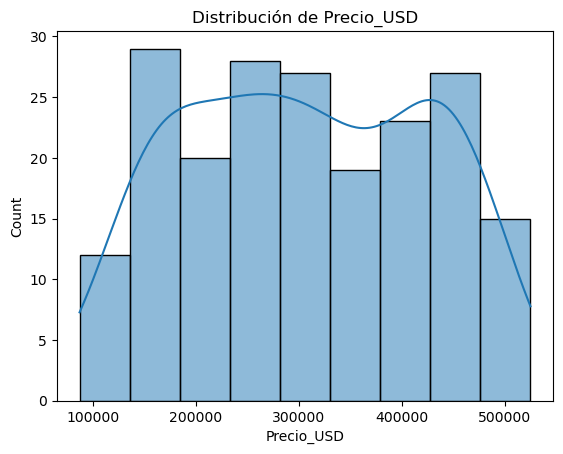

In [8]:
# Histograma con densidad

columna = 'Precio_USD'  # Reemplaza 'columna' con el nombre de la columna que deseas analizar
sns.histplot(df[columna], kde=True)
plt.title(f"Distribución de {columna}")
plt.show()

## Paso 5: Matriz de correlación

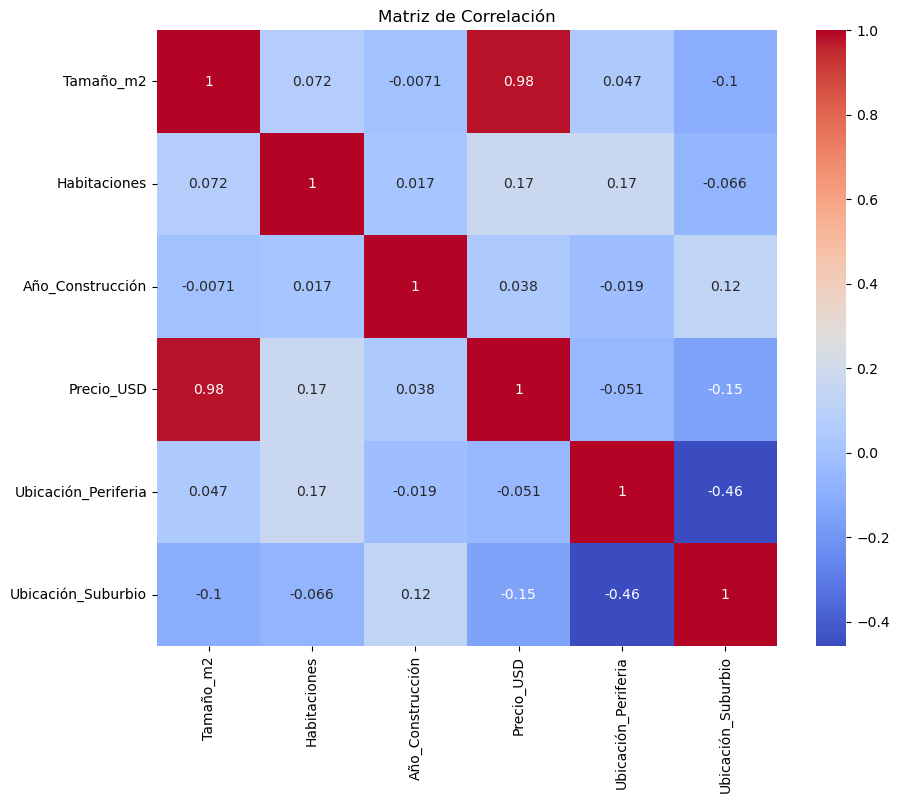

In [9]:
correlacion = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

# Paso 6 regresión lineal

In [10]:
# Variables

X = df.drop(["Precio_USD"],axis=1)
y = df["Precio_USD"]

# Verifica que no haya nulos
assert not X.isnull().any().any(), "Hay valores nulos en X"
assert not y.isnull().any(), "Hay valores nulos en y"

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicción (opcional)
y_pred = modelo.predict(X_test)
r2=modelo.score(X_test, y_test)
mse=mean_squared_error( y_test, y_pred)
print(f"R2={r2}\n"
      f"MSE={mse}")
ms=mse**.5
print(f"RMSE={ms}")


R2=0.997670173538748
MSE=40058143.458633155
RMSE=6329.15029515283


# Paso 7 modelo polinomial

In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler,PolynomialFeatures

PolynomialFeatures= PolynomialFeatures(degree=2, include_bias=False)
X_poly = PolynomialFeatures.fit_transform(X)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_poly, y, test_size=0.2, random_state=42)
df2 = pd.DataFrame(X_train2, columns=PolynomialFeatures.get_feature_names_out(X.columns))
modelo2 = LinearRegression()
modelo2.fit(X_train2, y_train2)   
# Predicción (opcional)
y_pred2 = modelo2.predict(X_test2)
r22=modelo2.score(X_test2, y_test2)
mse2=mean_squared_error( y_test2, y_pred2)
print(f"R2={r22}\n"
      f"MSE={mse2}")
ms2=mse2**.5
print(f"RMSE={ms2}")

R2=0.9978851752843358
MSE=36361485.82689361
RMSE=6030.0485758320065


# Paso 8 árbol de decisión

modelo con variables

In [ ]:
modelo4 = DecisionTreeRegressor(random_state=42)
modelo4.fit(X_train, y_train) 
# Predicción (opcional)
y_pred4 = modelo4.predict(X_test)
r4=modelo4.score(X_test, y_test)
mse4=mean_squared_error( y_test, y_pred)
print(f"R2={r4}\n"
      f"MSE={mse4}")
ms4=mse4**.5
print(f"RMSE={ms4}")  

R2=0.9644383824914509
MSE=611432825.35
RMSE=24727.167758358417


modelo con variables polinomiales

In [16]:
modelo3 = DecisionTreeRegressor(random_state=42)
modelo3.fit(X_train2, y_train2) 
# Predicción (opcional)
y_pred3 = modelo3.predict(X_test2)
r23=modelo3.score(X_test2, y_test2)
mse3=mean_squared_error( y_test2, y_pred3)
print(f"R2={r23}\n"
      f"MSE={mse3}")
ms3=mse3**.5
print(f"RMSE={ms3}")  

R2=0.9722250827920413
MSE=477551284.0
RMSE=21852.94680357777
